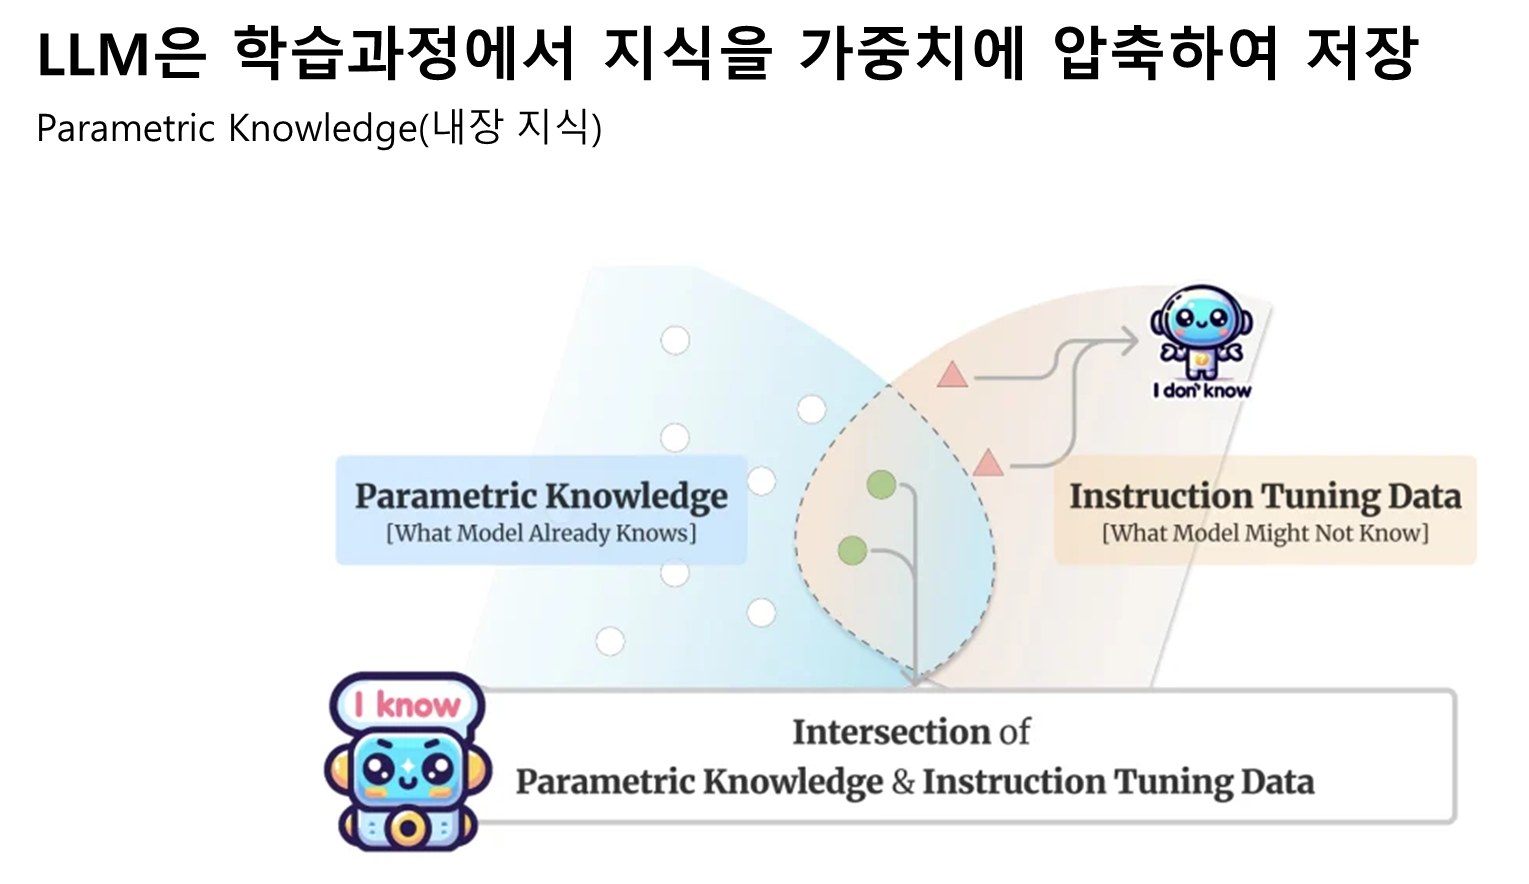

https://app.daily.dev/posts/95VSRYBVd

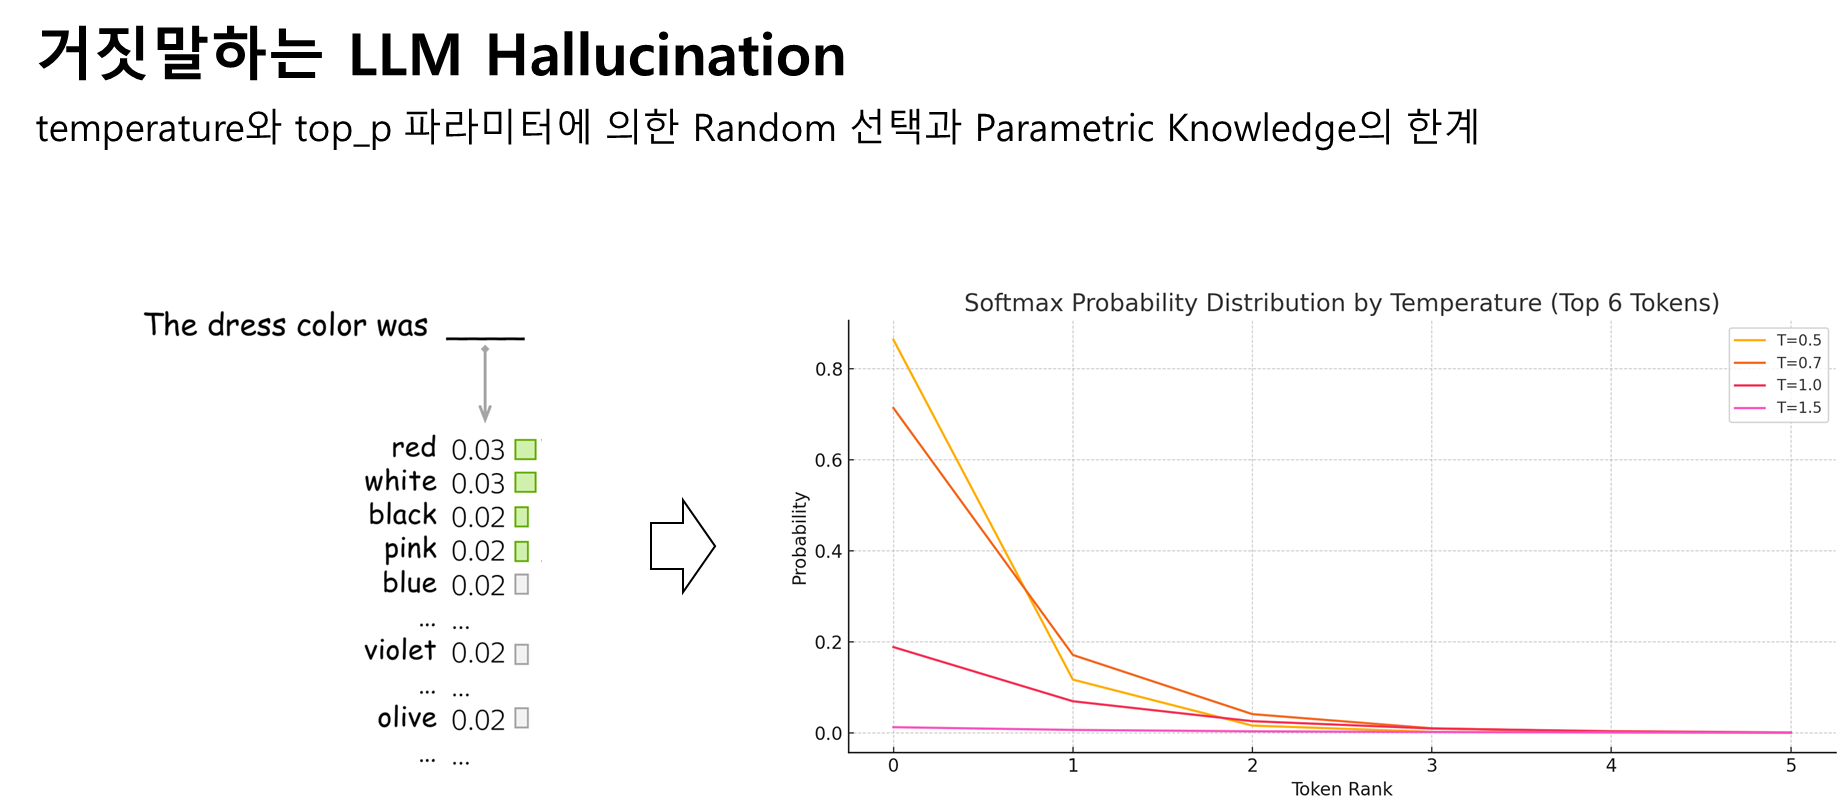

# **거짓말하는 LLM Hallucination을 없애기 위한 노력**

## **Contextual Knowledge(맥락 지식)**

https://platform.openai.com/playground/prompts?models=gpt-4.1

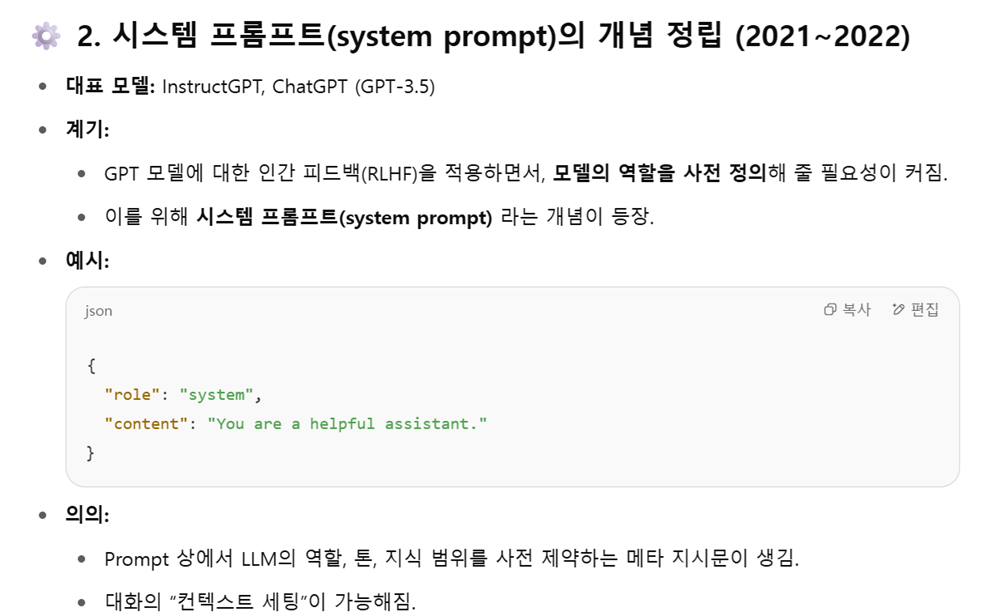

In [ ]:
pip install openai

In [ ]:
import os
from openai import OpenAI

# API 키 설정
os.environ['OPENAI_API_KEY'] = 'OPENAI_API_KEY'



client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

def chatGPT(msgs, temp=0.8, maxtoken=4096):
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=msgs,
        temperature=temp,
        max_tokens=maxtoken
    )
    return response


In [ ]:

response = chatGPT([{"role":"user", "content":"한양대 25년 2학기 도시빅데이터와 머신러닝 수업 듣는 학생들의 전공 알려줘"}], temp=0)
print(response.choices[0].message.content)


In [ ]:
msg = [
    {"role":"system", "content":"""
한양대 25년 2학기 도시빅데이터와 머신러닝 수업 학생 목록 :
[{'이름':'하**', '전공':'건축공학과', '학위:'박사', '학년',2 },
{'이름':'노**', '전공':'관광학과', '학위:'석사', '학년',4 },
{'이름':'김**', '전공':'관광학과', '학위:'석사', '학년',3 },
{'이름':'김**', '전공':'도시개발경영전공', '학위:'석사', '학년',3 },
{'이름':'윤**', '전공':'도시개발경영전공', '학위:'석사', '학년',2 },
{'이름':'손**', '전공':'도시공학과', '학위:'박사', '학년',3 },
{'이름':'유**', '전공':'도시공학과', '학위:'박사', '학년',3 },
{'이름':'응**', '전공':'도시공학과', '학위:'박사', '학년',3 },
{'이름':'정**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'서**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'최**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'공**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'양**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'이**', '전공':'도시공학과', '학위:'석사', '학년',1 },
{'이름':'지**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'하**', '전공':'도시공학과', '학위:'석사', '학년',1 },
{'이름':'이**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'송**', '전공':'도시공학과', '학위:'석사', '학년',2 },
{'이름':'강**', '전공':'도시공학과', '학위:'석사', '학년',1 },
{'이름':'사**', '전공':'도시공학과', '학위:'박사', '학년',2 },
{'이름':'이**', '전공':'도시공학과', '학위:'박사', '학년',1 },
{'이름':'최**', '전공':'도시공학과', '학위:'박사', '학년',2 },
{'이름':'마**', '전공':'도시공학과', '학위:'박사', '학년',2 },
{'이름':'박**', '전공':'디지털건설', '학위:'석사', '학년',2 },
{'이름':'김**', '전공':'디지털건설', '학위:'박사', '학년',2 },
{'이름':'강**', '전공':'비즈니스인포매틱스학과', '학위:'석사', '학년',2 },
{'이름':'나**', '전공':'비즈니스인포매틱스학과', '학위:'석사', '학년',2 },
{'이름':'폴**', '전공':'스마트시티공학과', '학위:'석사', '학년',3 },]
    """},
    {"role":"user", "content":"한양대 25년 2학기 도시빅데이터와 머신러닝 수업 듣는 학생들의 전공 알려줘"}
    ]

response = chatGPT(msg)
print(response.choices[0].message.content)


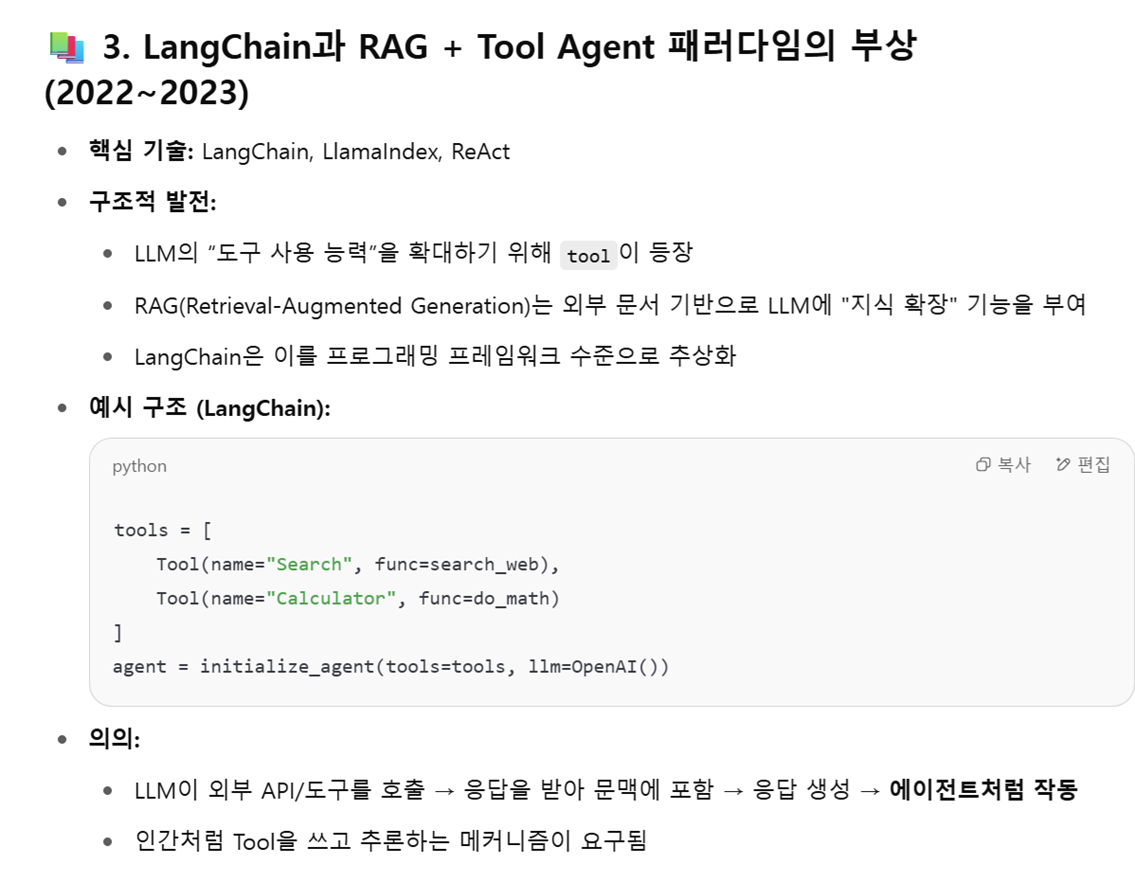

In [ ]:

response = chatGPT([{"role":"user", "content":"얼마전 열린 대한민국 대 가나 전 축구 결과 어떻게 됬지?"}], temp=0)
print(response.choices[0].message.content)


In [ ]:
!pip install -q langchain-classic langchain-openai langchain-community beautifulsoup4


In [ ]:
import requests
from bs4 import BeautifulSoup

from langchain_openai import ChatOpenAI
from langchain_classic.agents import create_tool_calling_agent, AgentExecutor
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool

In [ ]:

# 1. LLM 설정 (기존 키 사용)
# os.environ['OPENAI_API_KEY'] = '...' # (이미 설정되어 있다면 생략 가능)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# --- [핵심] 라이브러리 대신 직접 만든 도구들 ---

@tool
def my_web_search(keyword: str) -> str:
    """
    인터넷 검색이 필요할 때 사용합니다.
    """
    try:
        # 1. 진짜 브라우저인 척 헤더 설정 (차단 방지)
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }

        # 2. DuckDuckGo HTML 버전 페이지 요청 (JS 없이 가벼움)
        url = f"https://html.duckduckgo.com/html/?q={keyword}"
        response = requests.get(url, headers=headers, timeout=10)

        # 3. HTML 파싱 (BeautifulSoup 사용)
        soup = BeautifulSoup(response.text, 'html.parser')

        # 4. 결과 텍스트 추출 (제목과 요약문)
        results = []
        for result in soup.find_all('div', class_='result__body', limit=3): # 상위 3개만
            title = result.find('a', class_='result__a').get_text(strip=True)
            snippet = result.find('a', class_='result__snippet').get_text(strip=True)
            results.append(f"제목: {title}\n내용: {snippet}\n")

        if not results:
            return "검색 결과가 없습니다."

        return "\n---\n".join(results)

    except Exception as e:
        return f"검색 중 오류 발생: {e}"

# -----------------------------------------------

# # 3. 도구 리스트 등록


tools = [my_web_search]

prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 검색 도구와 API 도구를 가진 스마트 비서입니다. 질문에 따라 적절한 도구를 선택해서 답하세요."),
    ("user", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

result = agent_executor.invoke({"input": "얼마전 열린 대한민국 대 가나 전 축구 결과 어떻게 됬지?"})
print(result["output"])

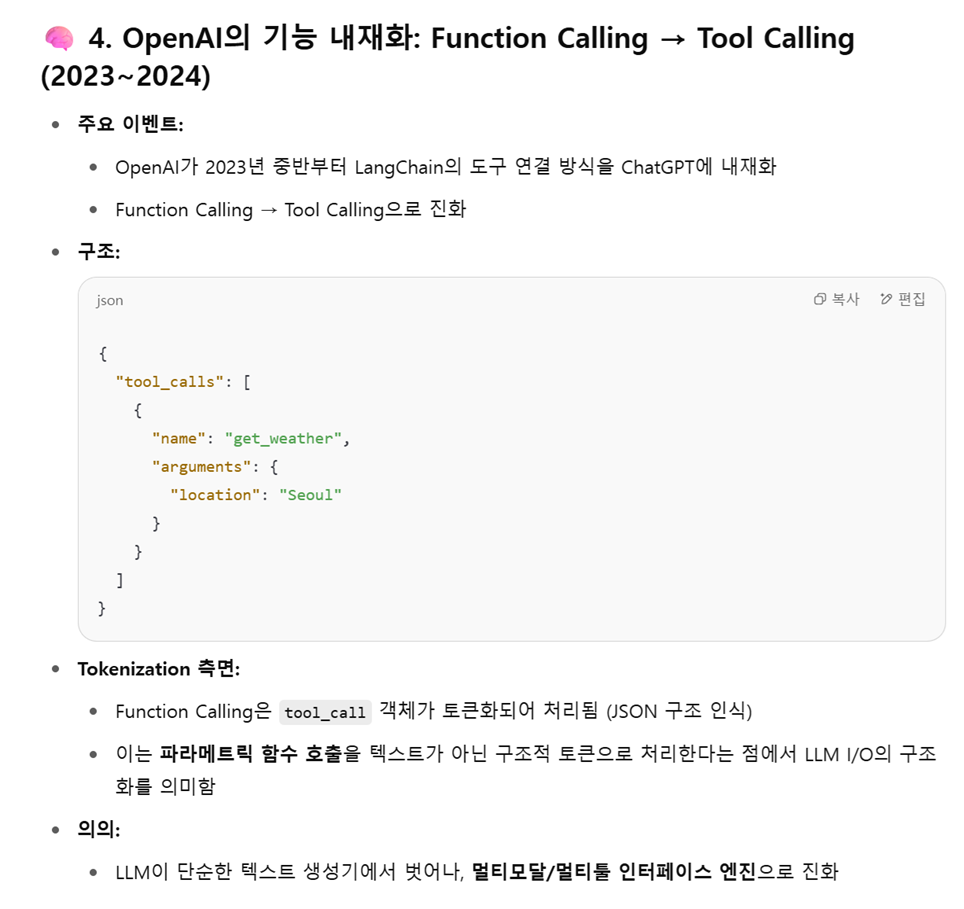

In [ ]:
import os
import json
from openai import OpenAI

# 1. 클라이언트 설정
client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

# 2. 도구(Tool) 정의 - AI에게 "이런 함수가 있다"고 알려주는 명세서(Schema)
# (실제 파이썬 함수 코드는 없어도 됩니다. AI는 이 정의만 보고 판단합니다.)
my_tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "web_search",
            "description": "인터넷 검색이 필요할 때 사용합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {
                        "type": "string",
                        "description": "검색할 키워드"
                    }
                },
                "required": ["query"]
            }
        }
    }
]

# 3. API 호출 (tools 파라미터에 명세서 전달)
print(">>> 질문: '최신 아이폰 모델 검색해줘' (API 호출 중...)")

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "최신 아이폰 모델 검색해줘"}],
    tools=my_tools_schema,
    tool_choice="auto"  # AI가 알아서 판단
)

# 4. 결과의 핵심 부분(Message)만 뽑아서 출력
msg = response.choices[0].message

print("\n" + "="*20 + " [API Raw Response] " + "="*20)
# 보기 좋게 딕셔너리 형태로 변환해서 출력
print(f"1. Content (대화 내용): {msg.content}")
print(f"2. Tool Calls (도구 호출 정보):\n")

print("")
print(msg)
print("")

# tool_calls가 리스트 형태로 들어옵니다.
if msg.tool_calls:
    for tool_call in msg.tool_calls:
        print(f"   - ID: {tool_call.id}")
        print(f"   - Type: {tool_call.type}")
        print(f"   - Function Name: {tool_call.function.name}")
        print(f"   - Arguments (JSON): {tool_call.function.arguments}")
else:
    print("   (도구 호출 없음)")
print("="*60)

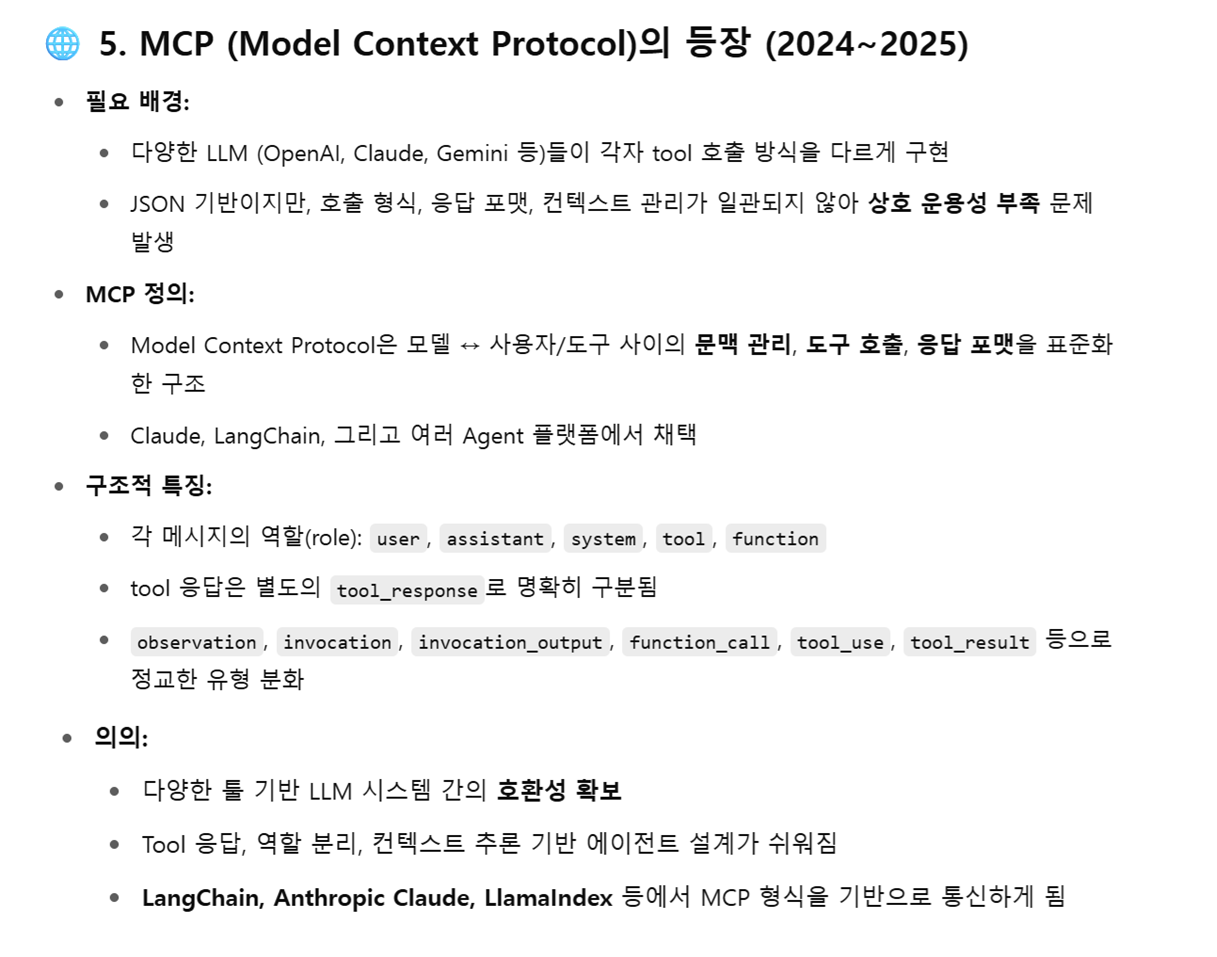